In [58]:
import sys
sys.path.append('../src')

from credit_risk.data.loader import load_german_credit

df = load_german_credit('../data/raw/german_credit.csv')
df.shape

(1000, 21)

In [59]:
df['class'].value_counts(normalize=True)

class
good    0.7
bad     0.3
Name: proportion, dtype: float64

<Axes: xlabel='class', ylabel='count'>

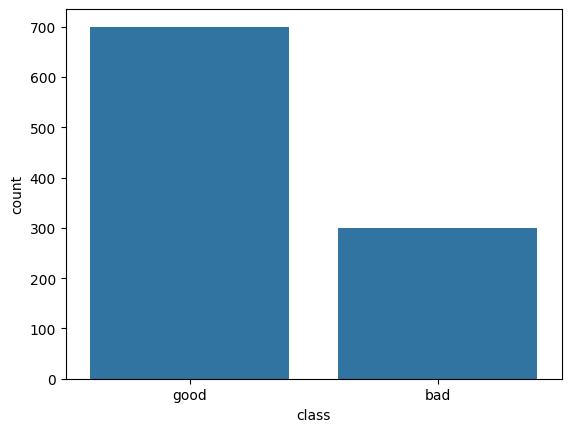

In [60]:
import seaborn as sns
sns.countplot(x='class', data=df)

| Колонка | Что означает |
|---|---|
| `checking_status` | Статус текущего счёта в банке (есть ли деньги на счету, есть ли счёт вообще) |
| `duration` | Срок кредита, в месяцах |
| `credit_history` | Кредитная история (были ли просрочки, все ли кредиты выплачены вовремя) |
| `purpose` | Цель кредита (машина, техника, образование, бизнес и т.п.) |
| `credit_amount` | Сумма кредита |
| `savings_status` | Размер сберегательного счёта/облигаций |
| `employment` | Стаж на текущем месте работы |
| `installment_commitment` | Размер платежа по кредиту в % от располагаемого дохода |
| `personal_status` | Семейное положение и пол |
| `other_parties` | Есть ли созаёмщик или поручитель |
| `residence_since` | Сколько лет живёт по текущему адресу |
| `property_magnitude` | Имущество в собственности (недвижимость, машина, ничего) |
| `age` | Возраст |
| `other_payment_plans` | Есть ли другие действующие рассрочки/кредиты (банк, магазин) |
| `housing` | Тип жилья (аренда, собственное, живёт бесплатно) |
| `existing_credits` | Количество текущих кредитов в этом банке |
| `job` | Тип занятости/квалификация |
| `num_dependents` | Количество иждивенцев |
| `own_telephone` | Есть ли телефон, зарегистрированный на человека |
| `foreign_worker` | Иностранный работник (да/нет) |
| `class` | **Таргет** — `good`/`bad`, вернул ли человек кредит |

In [61]:
df.head(3)

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good


In [62]:
num_cols = df.select_dtypes(include='number').columns.tolist()

In [63]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('class')

In [64]:
print(cat_cols)

['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


In [65]:
df[num_cols].describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


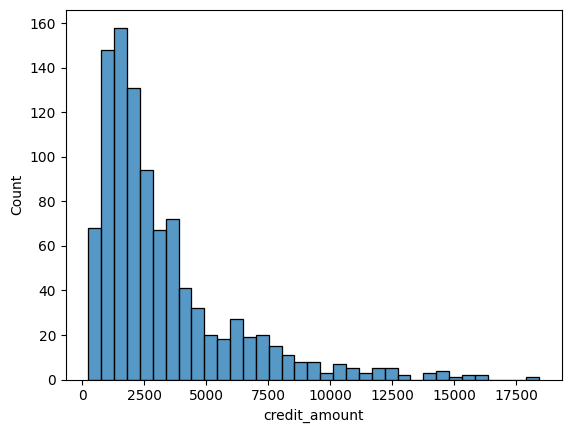

In [66]:
import matplotlib.pyplot as plt
sns.histplot(df['credit_amount'])
plt.show()

<Axes: xlabel='class', ylabel='credit_amount'>

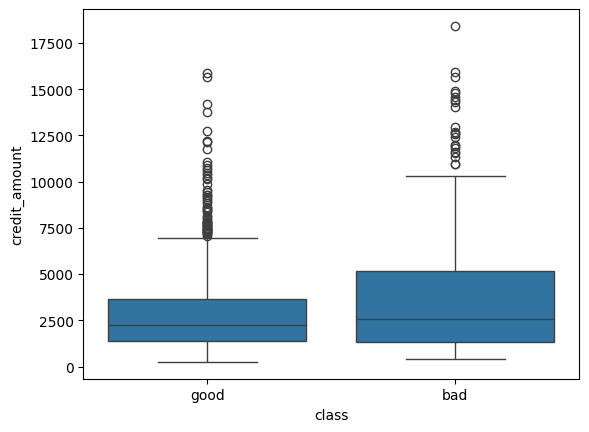

In [67]:
sns.boxplot(x=df['class'], y=df['credit_amount'], data=df)

<Axes: xlabel='class', ylabel='duration'>

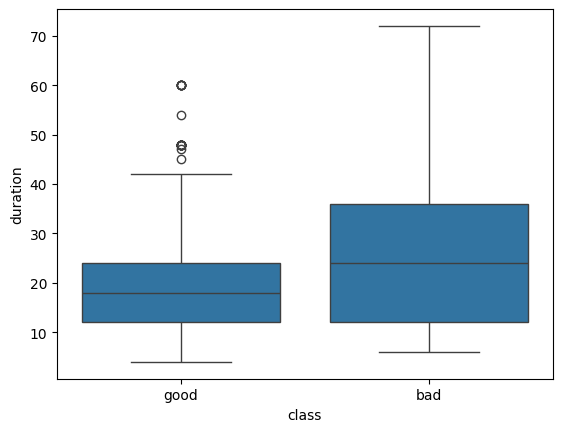

In [68]:
sns.boxplot(x=df['class'], y=df['duration'], data=df)

<Axes: >

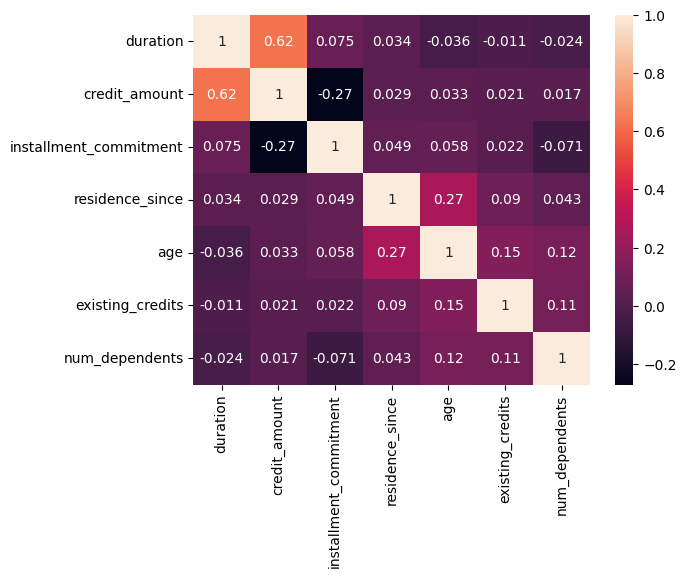

In [71]:
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True)

In [73]:
df[cat_cols]

,checking_status,credit_history,purpose,savings_status,employment,personal_status,other_parties,property_magnitude,other_payment_plans,housing,job,own_telephone,foreign_worker
0,<0,critical/other existing credit,radio/tv,no known savings,>=7,male single,none,real estate,none,own,skilled,yes,yes
1,0<=X<200,existing paid,radio/tv,<100,1<=X<4,female div/dep/mar,none,real estate,none,own,skilled,none,yes
2,no checking,critical/other existing credit,education,<100,4<=X<7,male single,none,real estate,none,own,unskilled resident,none,yes
3,<0,existing paid,furniture/equipment,<100,4<=X<7,male single,guarantor,life insurance,none,for free,skilled,none,yes
4,<0,delayed previously,new car,<100,1<=X<4,male single,none,no known property,none,for free,skilled,none,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking,existing paid,furniture/equipment,<100,4<=X<7,female div/dep/mar,none,real estate,none,own,unskilled resident,none,yes
996,<0,existing paid,used car,<100,1<=X<4,male div/sep,none,life insurance,none,own,high qualif/self emp/mgmt,yes,yes
997,no checking,existing paid,radio/tv,<100,>=7,male single,none,car,none,own,skilled,none,yes
998,<0,existing paid,radio/tv,<100,1<=X<4,male single,none,no known property,none,for free,skilled,yes,yes


<Axes: xlabel='checking_status', ylabel='count'>

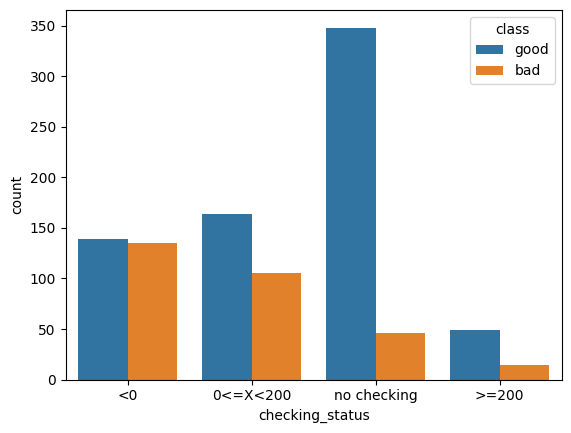

In [75]:
sns.countplot(x=df['checking_status'], hue=df['class'])